This notebook utilizes a sample iris image. In the first code cell, uncomment the following line to properly download:

!curl -L https://wld-ml-ai-data-public.s3.amazonaws.com/public-iris-images/example_orb_image_1.png -o ./sample_ir_image.png

List of nodes documented in this notebook:  eye_properties_estimation/MomentOfArea , eye_properties_estimation/BisectorsMethod, geometry_estimation/ FusionExtrapolation, geometry_estimation/LinearExtrapolation, geometry_estimation/LSQEllipseFitWithRefinement, validators/EyeCentersInsideImageValidator 

## 1. Moment of Area

algorithm:

      class_name: iris.MomentOfArea
      params: {}
    inputs:
      - name: geometries
        source_node: distance_filter
    callbacks:

#### General description: 
Uses a mathematical property of the iris polygon called "moment of area" to calculate the horizontal orientation of the iris. If we represent an iris as an ellipse, this is equivalent to finding the angle of the major axis.

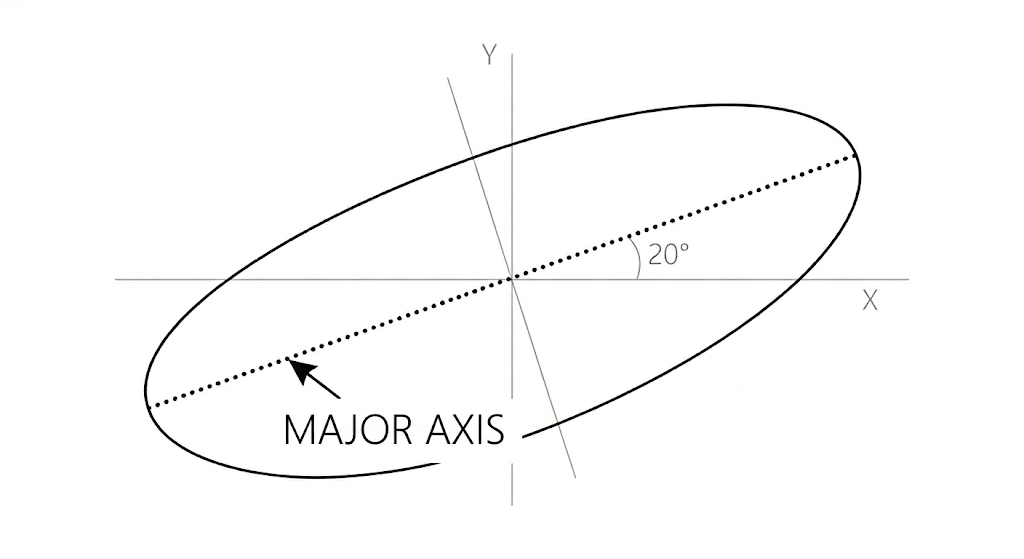

#### Parameters:

eccentricity_threshold: float in [0, 1] - threshold below which an error should be thrown because the eye is too circuar to reliably calculate the orientation. Eccentricity of an ellipse is a measure of "uncircularity," and if the image is too circular, the moment of areas method won't work. In reality, this parameter should rarely matter because the human eye is very elliptical.

#### Link to code: https://github.com/worldcoin/open-iris/blob/main/src/iris/nodes/eye_properties_estimation/moment_of_area.py

#### Explanation of code:

Calls an OpenCV2 function cv2.moments that returns a dictionary with all the calculated moment values. Essentially, this is information that can be used to calculate the orientation of the image. Then calculates the eccentricity of the iris using these moments and makes sure the image is elliptical enough to get a reliable estimate of the orientation. Finally, calculates this orientation using a helper function from iris.utils.math. Returns this angle in the form of an EyeOrientation object, which just holds an angle in [-pi/2, pi/2).

In [7]:
# don't need to run this cell
import cv2
from pydantic import Field

import iris.utils.math as math_utils
from iris.io.class_configs import Algorithm
from iris.io.dataclasses import EyeOrientation, GeometryPolygons
from iris.io.errors import EyeOrientationEstimationError


class MomentOfArea(Algorithm):
    """Estimate the eye orientation using the second order moments of the eyeball polygon.

    The eye orientation refers to the horizontal direction of the eye. It comes useful for determining the
    partial eye occlusion (e.g. occlusion at the horizontal middle third of the iris).

    References:
        [1] https://t1.daumcdn.net/cfile/tistory/15425F4150F4EBFC19
        [2] https://en.wikipedia.org/wiki/Image_moment
    """

    class Parameters(Algorithm.Parameters):
        eccentricity_threshold: float = Field(ge=0.0, le=1.0)

    __parameters_type__ = Parameters

    def __init__(self, eccentricity_threshold: float = 0.1) -> None:
        super().__init__(eccentricity_threshold=eccentricity_threshold)

    def run(self, geometries: GeometryPolygons) -> EyeOrientation:
        moments = cv2.moments(geometries.eyeball_array)

        eccentricity = math_utils.eccentricity(moments)
        if eccentricity < self.params.eccentricity_threshold:
            raise EyeOrientationEstimationError(
                "The eyeball is too circular to reliably determine its orientation. "
                f"Computed eccentricity: {eccentricity}. Threshold: {self.params.eccentricity_threshold}"
            )

        orientation = math_utils.orientation(moments)
        return EyeOrientation(angle=orientation)

#### Demonstration of algorithm on Test Image

In [5]:
import cv2
import iris
from pathlib import Path
from iris.nodes.eye_properties_estimation.moment_of_area import MomentOfArea

# ---- Load image ----
img_path = Path.home() / "Downloads/sample_ir_image.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
geometries = pipeline.call_trace.get("distance_filter")

print("geometry polygons type:", type(geometries))

# Run MomentOfArea in isolation
node = MomentOfArea(eccentricity_threshold=0.1)

result = node.run(
    geometries=geometries
)

print("\nResult type:", type(result))
print("Eye orientation angle (in radians):", result.angle) 

geometry polygons type: <class 'iris.io.dataclasses.GeometryPolygons'>

Result type: <class 'iris.io.dataclasses.EyeOrientation'>
Eye orientation angle: -0.09546997634564924


In [2]:
import cv2
import iris
from pathlib import Path
from iris.nodes.normalization.linear_normalization import LinearNormalization

# ---- Load image ----
img_path = Path.home() / "Downloads/sample_ir_image.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
noise_mask = pipeline.call_trace.get("noise_masks_aggregation")
geometry   = pipeline.call_trace.get("geometry_estimation")
eye_orient = pipeline.call_trace.get("eye_orientation")

print("noise_mask type:", type(noise_mask))
print("geometry type:  ", type(geometry))
print("eye_orient type:", type(eye_orient))

# ---- Run LinearNormalization in isolation ----
node = LinearNormalization(res_in_r=128, oversat_threshold=254)

result = node.run(
    image=ir_image,
    noise_mask=noise_mask,
    extrapolated_contours=geometry,
    eye_orientation=eye_orient
)

print("\nResult type:", type(result))
print("Normalized image shape:", result.normalized_image.shape)
print("Normalized mask shape: ", result.normalized_mask.shape)

noise_mask type: <class 'iris.io.dataclasses.NoiseMask'>
geometry type:   <class 'iris.io.dataclasses.GeometryPolygons'>
eye_orient type: <class 'iris.io.dataclasses.EyeOrientation'>

Result type: <class 'iris.io.dataclasses.NormalizedIris'>
Normalized image shape: (128, 512)
Normalized mask shape:  (128, 512)


#### Visualization

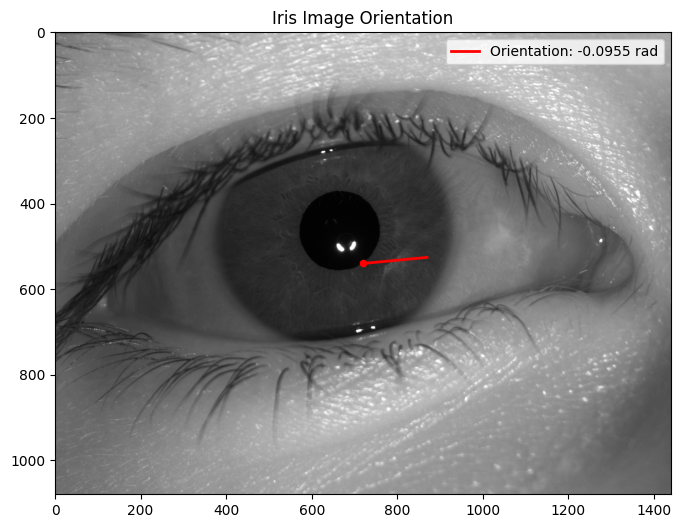

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Display the IR image
plt.figure(figsize=(10, 6))
plt.imshow(img_pixels, cmap='gray')

# Calculate the center of the image to start the orientation line
height, width = img_pixels.shape
cx, cy = width // 2, height // 2

# Define the line length for visualization
line_length = 150 

# result.angle is in radians; calculate the endpoint coordinates
end_x = cx + line_length * np.cos(result.angle)
end_y = cy + line_length * np.sin(result.angle)

# Plot the orientation line
plt.plot([cx, end_x], [cy, end_y], color='red', linewidth=2, label=f'Orientation: {result.angle:.4f} rad')
plt.scatter(cx, cy, color='red', s=20)  # Mark the center point

plt.title("Iris Image Orientation")
plt.legend()
plt.axis('on')
plt.show()

## 2. Bisectors Method

    class_name: iris.BisectorsMethod
      params: {}
    inputs:
      - name: geometries
        source_node: distance_filter
    callbacks:

#### General description

Algorithm used to estimate the center of the eye (i.e. the center of the pupil) using the perpendicular bisectors method for finding the center of a circle. The algorithm works as follows: pick 2 points on the edge of the circle, connect them with a line segment, find the perpendicular bisector of this line segment. Then repeat this for other pairs of 2 points. Finally, the intersection of all these bisectors gives an accurate estimate of the circle's center.

#### Parameter Description

num_bisectors: int, default 100. Number of generated bisectors

min_distance_between_sector_points: float, default 0.75. Makes sure that the pairs of points whose perp bisector is being calculated are not too close. (The calculated bisector of a pair of points that is too close is highly sensitive to noise.)

max_iterations: int, default 50. Max number of iterations during the algorithm that finds a perpendicular bisector given two points

#### Link to code

https://github.com/worldcoin/open-iris/blob/main/src/iris/nodes/eye_properties_estimation/bisectors_method.py

#### Description of code

There are three helper functions. _find_best_intersection does the final work of finding the approximate intersection of all the perpendicular bisector lines. The resulting point is BisectorsMethod's estimate of the center of the circle. _calculate_perpendicular_bisectors takes a numpy ndarray representing the vertices of the image of an iris and randomly chooses a bunch of pairs of vertices and finds the perpendicular bisectors of the line segment connecting these vertices. Finally, _find_center_coords uses these two previous helper functions to calculate the estimated center of a numpy array representing the vertices. 

The main run function calls _find_center_coords on the pupil array and the iris array, finding the estimated centers for both. The returned object is called "EyeCenters" and stores four values: pupil_x, pupil_y, iris_x, iris_y that give the (x,y) coords of the pupil and iris

#### Demonstration of algorithm on test image

In [11]:
import cv2
import iris
from pathlib import Path
from iris.nodes.eye_properties_estimation.bisectors_method import BisectorsMethod

# ---- Load image ----
img_path = Path.home() / "Downloads/sample_ir_image.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
geometries = pipeline.call_trace.get("distance_filter")

print("geometries type:", type(geometries))

node = BisectorsMethod(num_bisectors=100, 
                       min_distance_between_sector_points=0.75, 
                       max_iterations=50)

result = node.run(
    geometries=geometries
)

print("\nResult type:", type(result))
print(f"Pupil center coords: ({result.pupil_x}, {result.pupil_y})")
print(f"Iris center coords: ({result.iris_x}, {result.iris_y})")

geometries type: <class 'iris.io.dataclasses.GeometryPolygons'>

Result type: <class 'iris.io.dataclasses.EyeCenters'>
Pupil coords: (665.7943711373364, 465.3867923138916)
Iris coords: (651.6534392787831, 466.10624561426255)


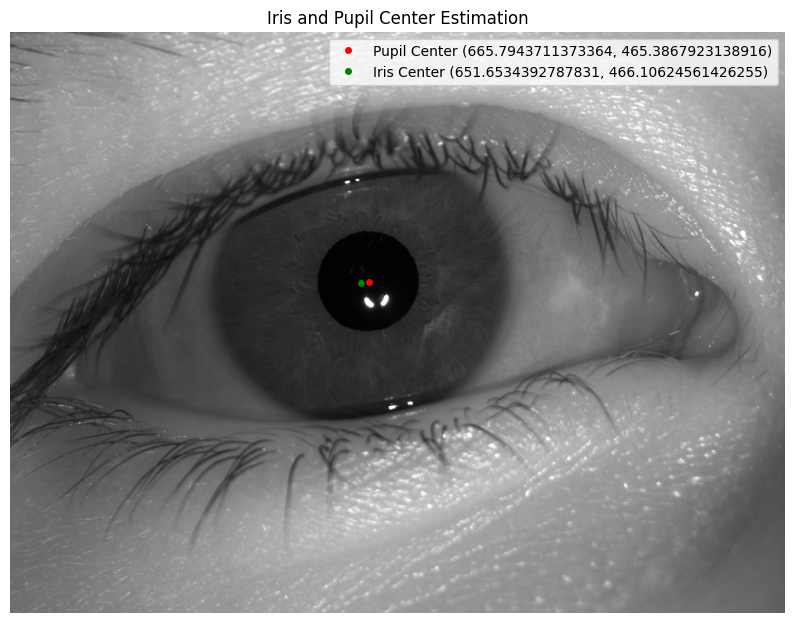

In [13]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- Load image ---
img_path = Path.home() / "Downloads/sample_ir_image.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

pupil_center = (result.pupil_x, result.pupil_y)
iris_center = (result.iris_x, result.iris_y)

# --- Plotting ---
plt.figure(figsize=(10, 8))
plt.imshow(img_pixels, cmap='gray')

plt.plot(pupil_center[0], pupil_center[1], 'ro', markersize=4, label=f'Pupil Center {pupil_center}')
plt.plot(iris_center[0], iris_center[1], 'go', markersize=4, label=f'Iris Center {iris_center}')

plt.title("Iris and Pupil Center Estimation")
plt.legend(loc='upper right')
plt.axis('off')
plt.show()

## 3. FusionExtrapolation


 
      class_name: iris.FusionExtrapolation
      params:
        circle_extrapolation:
          class_name: iris.LinearExtrapolation
          params:
            dphi: 0.703125
        ellipse_fit:
          class_name: iris.LSQEllipseFitWithRefinement
          params:
            dphi: 0.703125
        algorithm_switch_std_threshold: 0.014
        algorithm_switch_std_conditioned_multiplier: 2.0
    inputs:
      - name: input_polygons
        source_node: smoothing
      - name: eye_center
        source_node: eye_center_estimation
    callbacks:

#### General Description

Does extrapolation, i.e. filling in missing iris parts that have been occluded by something. FusionExtrapolation in particular uses two strategies, circle-like extrapolation (LinearExtrapolation Python class) and ellipse-like extrapolation (LSQEllipseFitWithRefinement Python class). FusionExtrapolation picks which strategy to use by estimating how circular the iris is. It does this by calculating the distance between points on the iris edge and points on the pupil edge and seeing how much these distances vary. The idea is that if the iris and pupil are perfectly circular, the variance will be zero whereas if they are more elliptical, the variance will be higher.

#### Parameter description

        circle_extrapolation: Algorithm = LinearExtrapolation(dphi=360 / 512) : algorithm to do extrapolation assuming the shape of the iris is circular. This will never be changed from the default argument since no other algorithm for circle extrapolation other than LinearExtrapolation has been implemented
        
        ellipse_fit: Algorithm = LSQEllipseFitWithRefinement(dphi=360 / 512) : algorithm to do extrapolation assuming the shape of the iris is elliptical
        
        algorithm_switch_std_threshold: float = 0.014 : threshold for determining whether to use circular or elliptical extrapolation. The higher the threshold, the more bias towards circular extrapolation since a low standard deviation (std) of radii lengths corresponds to a circular shape.
        
        algorithm_switch_std_conditioned_multiplier: float = 2.0 : another way to control bias. The higher the multiplier here, the more bias towards using elliptical extrapolation.

#### Link to code: https://github.com/worldcoin/open-iris/blob/main/src/iris/nodes/geometry_estimation/fusion_extrapolation.py

#### Description of Code

There are two helper functions: _relative_std and _squared_relative_radii. _relative_std takes a numpy array and simply returns its normalized standard deviation, ie std / mean. _squared_relative_radii takes two numpy arrays of size (N,2) representing the iris polygon and pupil polygons (so for example each row in the iris array will be a 2D point on the edge of the iris) and returns the "squared relative radii." This is an (N,1) array. The nth entry in this array gives you information about how far the nth point in the iris polygon is from the nth point in the pupil polygon. So if the iris and pupil are both perfectly circular, this will be an array of very small numbers and if one or both is elliptical, this will be an array of larger numbers. 

The run function calculates the radius standard deviation individually for both the iris and pupil polygon arrays. If either is elliptical (exceeds the threshold set by the user), it returns the extrapolated version of the polygon calculated using LSQEllipseFitWithRefinement). Otherwise, returns extrapolated polygon using circular extrapolation.

#### Demonstration of algorithm on test image

In [26]:
import cv2
import iris
from pathlib import Path
from iris.nodes.geometry_estimation.fusion_extrapolation import FusionExtrapolation
from iris.nodes.geometry_estimation.linear_extrapolation import LinearExtrapolation
from iris.nodes.geometry_estimation.lsq_ellipse_fit_with_refinement import LSQEllipseFitWithRefinement

# ---- Load image ----
img_path = Path.home() / "Downloads/sample_ir_image.png"
img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

if img_pixels is None:
    raise FileNotFoundError(f"Could not load image at {img_path}")

ir_image = iris.IRImage(img_data=img_pixels, image_id="example", eye_side="left")

# ---- Run full pipeline (populates call_trace) ----
pipeline = iris.IRISPipeline()
output = pipeline(ir_image)

# ---- Pull intermediate outputs from call_trace ----
input_polygons = pipeline.call_trace.get("smoothing")
eye_center = pipeline.call_trace.get("eye_center_estimation")

print("input_polygons type:", type(input_polygons))
print("eye_center type:", type(eye_center))

linear_extrapolation = LinearExtrapolation(dphi=360/400)
ellipse_fit = LSQEllipseFitWithRefinement(dphi=360/400)

node = FusionExtrapolation(
    circle_extrapolation=linear_extrapolation,
    ellipse_fit=ellipse_fit,
    algorithm_switch_std_threshold=0.014,
    algorithm_switch_std_conditioned_multiplier=2
)

result = node.run(
    input_polygons=input_polygons,
    eye_center=eye_center
)

print("\nResult type:", type(result))

input_polygons type: <class 'iris.io.dataclasses.GeometryPolygons'>
eye_center type: <class 'iris.io.dataclasses.EyeCenters'>

Result type: <class 'iris.io.dataclasses.GeometryPolygons'>


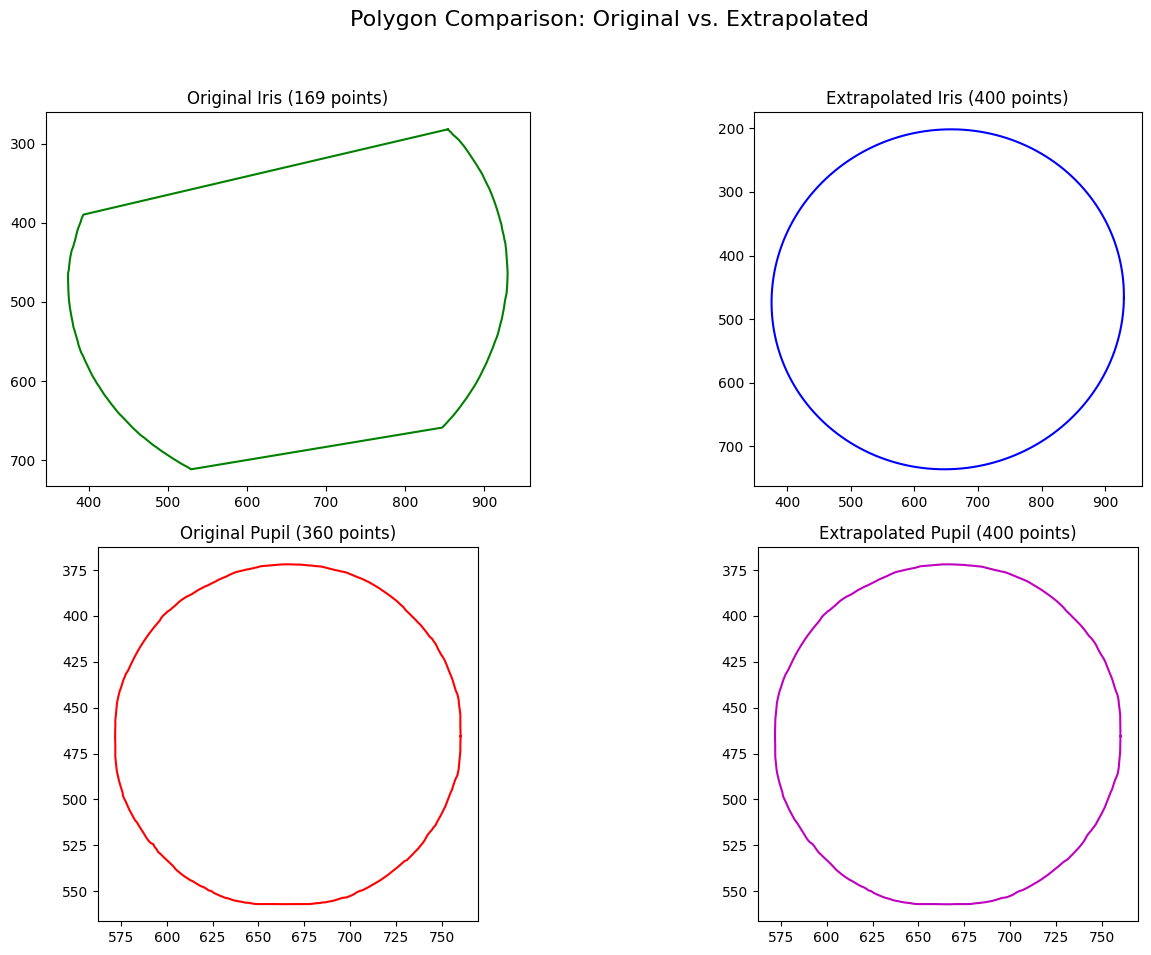

In [28]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Helper function to ensure the polygon is closed for plotting
def get_closed_poly(poly_vertices):
    return np.vstack([poly_vertices, poly_vertices[0]])

# --- Iris Comparison (Top Row) ---
# Original Iris
iris_orig = get_closed_poly(input_polygons.iris_array)
axes[0, 0].plot(iris_orig[:, 0], iris_orig[:, 1], 'g-', linewidth=1.5)
axes[0, 0].set_title(f"Original Iris ({len(input_polygons.iris_array)} points)")
axes[0, 0].invert_yaxis() # Match image coordinate system
axes[0, 0].set_aspect('equal')

# Extrapolated Iris
iris_extrap = get_closed_poly(result.iris_array)
axes[0, 1].plot(iris_extrap[:, 0], iris_extrap[:, 1], 'b-', linewidth=1.5)
axes[0, 1].set_title(f"Extrapolated Iris ({len(result.iris_array)} points)")
axes[0, 1].invert_yaxis()
axes[0, 1].set_aspect('equal')

# --- Pupil Comparison (Bottom Row) ---
# Original Pupil
pupil_orig = get_closed_poly(input_polygons.pupil_array)
axes[1, 0].plot(pupil_orig[:, 0], pupil_orig[:, 1], 'r-', linewidth=1.5)
axes[1, 0].set_title(f"Original Pupil ({len(input_polygons.pupil_array)} points)")
axes[1, 0].invert_yaxis()
axes[1, 0].set_aspect('equal')

# Extrapolated Pupil
pupil_extrap = get_closed_poly(result.pupil_array)
axes[1, 1].plot(pupil_extrap[:, 0], pupil_extrap[:, 1], 'm-', linewidth=1.5)
axes[1, 1].set_title(f"Extrapolated Pupil ({len(result.pupil_array)} points)")
axes[1, 1].invert_yaxis()
axes[1, 1].set_aspect('equal')

plt.suptitle("Polygon Comparison: Original vs. Extrapolated", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 4. LinearExtrapolation

    class_name: iris.LinearExtrapolation
          params:
            dphi: 0.703125

#### General description

Does circular extrapolation to fill in missing parts of the iris polygon (perhaps caused by an obstruction while taking the photo, for example). The reason the word "linear" is used even though we're talking about circular objects is that coordinates are expressed in polar form, and circles are lines in polar coordinates. 

Takes as input the iris and pupil and eyeball polygons as well as their respective center points, and returns the iris and pupil and eyeball polygons with extrapolation complete

#### Parameters

dphi (float, optional) : change in angle used during extrapolation. Determines how many extra points are added to the iris/pupil arrays. The smaller dphi is, the more points are added

#### Link to code: https://github.com/worldcoin/open-iris/blob/main/src/iris/nodes/geometry_estimation/linear_extrapolation.py

#### Description of code

There is only one helper function, _estimate, and it does essentially all the work. The run function simply calls _estimate on the pupil array and then on the iris array and returns the results. _estimate is given a numpy array containing vertices of a polygon (i.e. either the iris or pupil) and the center of the circle, and then it uses this to complete the circle. First it converts everything to polar coordinates, then it uses numpy to do linear interpolation, then it converts back to cartesian coordinates and returns the result

#### For demonstration of the algorithm on a test image, see documentation on 3. FusionExtrapolation

## 5. LSQEllipseFitWithRefinement

    class_name: iris.LSQEllipseFitWithRefinement
              params:
                dphi: 0.703125

## 6. EyeCentersInsideImageValidator

    name: eye_centers_inside_image_validator
        algorithm:
          class_name: iris.nodes.validators.cross_object_validators.EyeCentersInsideImageValidator
          params:
            min_distance_to_border: 0.0
        inputs:
          - name: ir_image
            source_node: input
          - name: eye_centers
            source_node: eye_center_estimation
        callbacks: